## import và cấu hình path

In [43]:
import os
import json
import torch
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

ANN_PATH = r"../data/iu_xray/annotation.json"
IMAGE_DIR = r"../data/iu_xray/images"

print(os.path.exists(ANN_PATH))
print(os.path.exists(IMAGE_DIR))

True
True


## đọc annotation.json

In [44]:
with open(ANN_PATH, "r", encoding="utf-8") as f:
    ann = json.load(f)

print(ann.keys())

for split in ["train", "val", "test"]:
    print(split, len(ann[split]))

dict_keys(['train', 'val', 'test'])
train 2069
val 296
test 590


## xem vài sample

In [45]:
for split in ["train", "val", "test"]:
    print("====", split, "====")
    sample = ann[split][0]
    print(sample.keys())
    print("id:", sample["id"])
    print("image_path:", sample["image_path"])
    print("report:", sample["report"][:300])

==== train ====
dict_keys(['id', 'report', 'image_path', 'split'])
id: CXR2384_IM-0942
image_path: ['CXR2384_IM-0942/0.png', 'CXR2384_IM-0942/1.png']
report: The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.
==== val ====
dict_keys(['id', 'report', 'image_path', 'split'])
id: CXR2279_IM-0865
image_path: ['CXR2279_IM-0865/0.png', 'CXR2279_IM-0865/1.png']
report: Heart size is enlarged. The aorta is unfolded. Otherwise the mediastinal contour is normal. There are streaky bibasilar opacities. There are no nodules or masses. No visible pneumothorax. No visible pleural fluid. The XXXX are grossly normal. There is no visible free intraperitoneal air under the di
==== test ====
dict_keys(['id', 'report', 'image_path', 'split'])
id: CXR3030_IM-1405
image_path: ['CXR3030_IM-1405/0.png', 'CXR3030_IM-1405/1.pn

## kiểm tra thiếu ảnh

In [46]:
missing = []

for split in ["train", "val", "test"]:
    for item in ann[split]:
        for img_rel in item["image_path"]:
            img_path = os.path.join(IMAGE_DIR, img_rel)
            if not os.path.exists(img_path):
                missing.append((split, item["id"], img_rel))

print("Missing images:", len(missing))
print(missing[:10])

Missing images: 0
[]


## thống kê số ảnh mỗi study

In [47]:
for split in ["train", "val", "test"]:
    counts = Counter(len(item["image_path"]) for item in ann[split])
    print(split, counts)

train Counter({2: 2069})
val Counter({2: 296})
test Counter({2: 590})


## hiển thị ảnh + report

ID: CXR2384_IM-0942
REPORT:
The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.


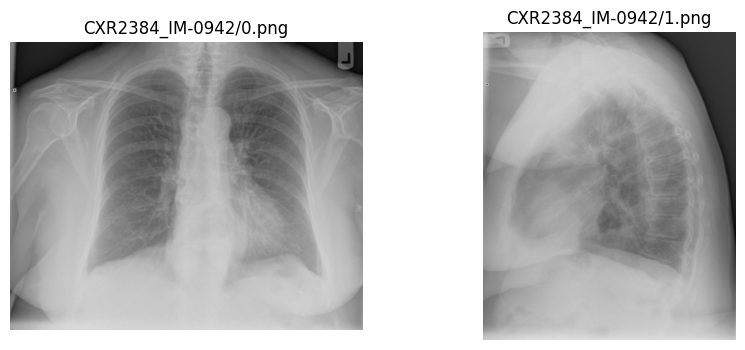

In [48]:
idx = 0
split = "train"
item = ann[split][idx]

print("ID:", item["id"])
print("REPORT:")
print(item["report"])

fig, axes = plt.subplots(1, len(item["image_path"]), figsize=(10, 4))

if len(item["image_path"]) == 1:
    axes = [axes]

for ax, rel_path in zip(axes, item["image_path"]):
    img_path = os.path.join(IMAGE_DIR, rel_path)
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img, cmap="gray")
    ax.set_title(rel_path)
    ax.axis("off")

plt.show()

## test tokenizer

In [49]:
import sys
sys.path.append("..")

from modules.tokenizers import Tokenizer

In [58]:
class Args:
    image_dir = IMAGE_DIR
    ann_path = ANN_PATH
    dataset_name = "iu_xray"
    threshold = 3
    max_seq_length = 60

    batch_size = 64
    num_workers = 0

args = Args()

args = Args()
tokenizer = Tokenizer(args)

print("vocab size:", len(tokenizer.token2idx))
print("first tokens:", list(tokenizer.token2idx.items())[:20])

vocab size: 760
first tokens: [('.', 1), ('1', 2), ('10', 3), ('10th', 4), ('12', 5), ('13', 6), ('17', 7), ('2', 8), ('3', 9), ('5', 10), ('5th', 11), ('6th', 12), ('7', 13), ('7th', 14), ('8', 15), ('8th', 16), ('9th', 17), ('<unk>', 18), ('a', 19), ('abdomen', 20)]


In [59]:
raw_report = ann["train"][0]["report"]
clean_report = tokenizer.clean_report(raw_report)

print("RAW:")
print(raw_report)

print("\nCLEAN:")
print(clean_report)

RAW:
The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.

CLEAN:
the heart size and pulmonary vascularity appear within normal limits . a large hiatal hernia is noted . the lungs are free of focal airspace disease . no pneumothorax or pleural effusion is seen . degenerative changes are present in the spine .


In [60]:
tokens = clean_report.split()
ids = [tokenizer.token2idx.get(t, tokenizer.token2idx["<unk>"]) for t in tokens]

print(tokens[:30])
print(ids[:30])

decoded = [tokenizer.idx2token.get(i, "<missing>") for i in ids[:30]]
print(decoded)

['the', 'heart', 'size', 'and', 'pulmonary', 'vascularity', 'appear', 'within', 'normal', 'limits', '.', 'a', 'large', 'hiatal', 'hernia', 'is', 'noted', '.', 'the', 'lungs', 'are', 'free', 'of', 'focal', 'airspace', 'disease', '.', 'no', 'pneumothorax', 'or']
[684, 314, 624, 49, 550, 725, 62, 752, 451, 388, 1, 19, 375, 319, 318, 364, 455, 1, 684, 406, 68, 293, 467, 284, 40, 225, 1, 445, 521, 475]
['the', 'heart', 'size', 'and', 'pulmonary', 'vascularity', 'appear', 'within', 'normal', 'limits', '.', 'a', 'large', 'hiatal', 'hernia', 'is', 'noted', '.', 'the', 'lungs', 'are', 'free', 'of', 'focal', 'airspace', 'disease', '.', 'no', 'pneumothorax', 'or']


In [61]:
from modules.datasets import IuxrayMultiImageDataset
import sys
sys.path.append("..")


In [62]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [63]:
from modules.tokenizers import Tokenizer
from modules.datasets import IuxrayMultiImageDataset

tokenizer = Tokenizer(args)

dataset = IuxrayMultiImageDataset(
    args=args,
    tokenizer=tokenizer,
    split="train",

    transform=transform
)

print("Dataset length:", len(dataset))

sample = dataset[0]
print(type(sample))

for i, x in enumerate(sample):
    if torch.is_tensor(x):
        print(i, x.shape, x.dtype, x.min().item(), x.max().item())
    else:
        print(i, type(x), x)

Dataset length: 2069
<class 'tuple'>
0 <class 'str'> CXR2384_IM-0942
1 torch.Size([2, 3, 224, 224]) torch.float32 -1.9637812376022339 2.0648367404937744
2 <class 'list'> [0, 684, 314, 624, 49, 550, 725, 62, 752, 451, 388, 1, 19, 375, 319, 318, 364, 455, 1, 684, 406, 68, 293, 467, 284, 40, 225, 1, 445, 521, 475, 517, 239, 364, 604, 1, 198, 143, 68, 534, 341, 684, 639, 1, 0]
3 <class 'list'> [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
4 <class 'int'> 45


In [64]:
from modules.dataloaders import R2DataLoader

train_loader = R2DataLoader(args, tokenizer, split="train", shuffle=False)

batch = next(iter(train_loader))

for i, x in enumerate(batch):
    if torch.is_tensor(x):
        print(i, x.shape, x.dtype)
    else:
        print(i, type(x), x)

0 <class 'tuple'> ('CXR2384_IM-0942', 'CXR2926_IM-1328', 'CXR1451_IM-0291', 'CXR2887_IM-1289', 'CXR1647_IM-0424', 'CXR2434_IM-0976', 'CXR3655_IM-1817', 'CXR3299_IM-1575', 'CXR1419_IM-0267', 'CXR2867_IM-1274', 'CXR177_IM-0503', 'CXR3597_IM-1775', 'CXR2365_IM-0927', 'CXR718_IM-2280', 'CXR229_IM-0873', 'CXR1237_IM-0159', 'CXR2704_IM-1171', 'CXR1324_IM-0209', 'CXR3516_IM-1715', 'CXR3102_IM-1454', 'CXR1267_IM-0179', 'CXR3766_IM-1885', 'CXR1145_IM-0097', 'CXR1573_IM-0374', 'CXR2372_IM-0933-0001', 'CXR3115_IM-1463', 'CXR3706_IM-1851', 'CXR1616_IM-0399', 'CXR2845_IM-1254', 'CXR951_IM-2447', 'CXR3404_IM-1647', 'CXR3956_IM-2021', 'CXR1981_IM-0638', 'CXR930_IM-2429', 'CXR2269_IM-0858', 'CXR2328_IM-0898', 'CXR1167_IM-0112', 'CXR152_IM-0335', 'CXR1491_IM-0317', 'CXR880_IM-2395', 'CXR22_IM-0810', 'CXR2643_IM-1129', 'CXR1396_IM-0252', 'CXR2438_IM-0978', 'CXR3141_IM-1477', 'CXR2868_IM-1275', 'CXR3665_IM-1823', 'CXR1135_IM-0091', 'CXR1151_IM-0102', 'CXR1934_IM-0604', 'CXR3537_IM-1730', 'CXR1877_IM-0568

In [68]:
print(type(batch))
print("len batch:", len(batch))

for i, x in enumerate(batch):
    print("==== index", i, "====")
    print("type:", type(x))

    if torch.is_tensor(x):
        print("shape:", x.shape)
        print("dtype:", x.dtype)
    elif isinstance(x, (list, tuple)):
        print("len:", len(x))
        print("first type:", type(x[0]))
        print("first value:", x[0])
    else:
        print("value:", x)

<class 'tuple'>
len batch: 4
==== index 0 ====
type: <class 'tuple'>
len: 64
first type: <class 'str'>
first value: CXR2384_IM-0942
==== index 1 ====
type: <class 'torch.Tensor'>
shape: torch.Size([64, 2, 3, 224, 224])
dtype: torch.float32
==== index 2 ====
type: <class 'torch.Tensor'>
shape: torch.Size([64, 60])
dtype: torch.int64
==== index 3 ====
type: <class 'torch.Tensor'>
shape: torch.Size([64, 60])
dtype: torch.float32


In [69]:
image_ids, images, reports_ids, reports_masks = batch

print("image_ids:", image_ids[:2])
print("images:", images.shape)
print("reports_ids:", reports_ids.shape)
print("reports_masks:", reports_masks.shape)

print("mask sum per sample:", reports_masks.sum(dim=1)[:10])
print("first ids:", reports_ids[0][:50])
print("first mask:", reports_masks[0][:50])

image_ids: ('CXR2384_IM-0942', 'CXR2926_IM-1328')
images: torch.Size([64, 2, 3, 224, 224])
reports_ids: torch.Size([64, 60])
reports_masks: torch.Size([64, 60])
mask sum per sample: tensor([45., 21., 26., 42., 36., 26., 39., 38., 35., 60.])
first ids: tensor([  0, 684, 314, 624,  49, 550, 725,  62, 752, 451, 388,   1,  19, 375,
        319, 318, 364, 455,   1, 684, 406,  68, 293, 467, 284,  40, 225,   1,
        445, 521, 475, 517, 239, 364, 604,   1, 198, 143,  68, 534, 341, 684,
        639,   1,   0,   0,   0,   0,   0,   0])
first mask: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.])


64 mẫu / batch

mỗi mẫu có 2 ảnh

ảnh RGB 224x224

report đã pad/cắt về 60 token

mask đánh dấu token thật/padding

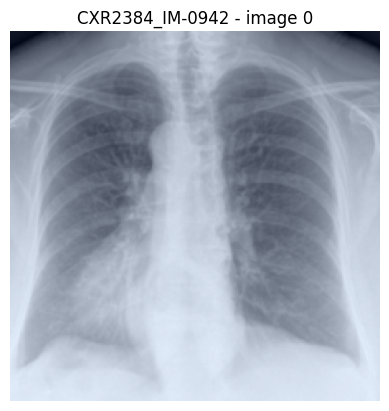

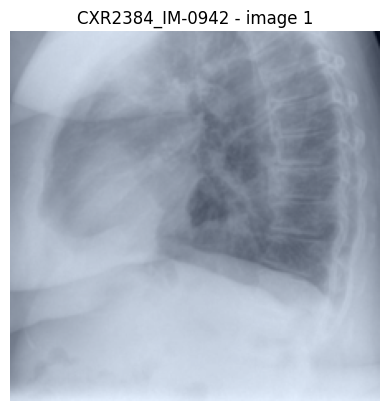

In [71]:
imgs = images[0]  # [2, 3, 224, 224]

for i in range(imgs.shape[0]):
    img = imgs[i].permute(1, 2, 0).detach().cpu()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img)
    plt.title(f"{image_ids[0]} - image {i}")
    plt.axis("off")
    plt.show()